In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

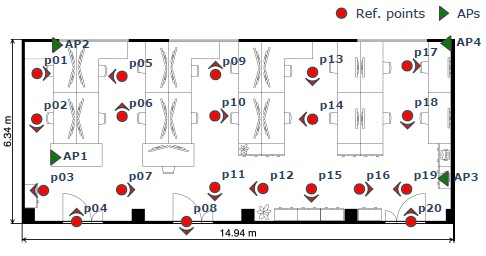

In [94]:
display(Image(r"C:\Users\franc\rtt\planol.jpg"))

## Fitxer `aps.csv`

Conté la informació dels quatre punts d'accés (Access Points) desplegats
a l'entorn experimental. Té les següents columnes:

| Columna | Descripció |
|---|---|
| `mac` | Adreça MAC del punt d'accés. Identificador físic únic del dispositiu |
| `id` | Nom llegible de l'AP (AP1, AP2, AP3, AP4) |
| `x` | Coordenada x de l'AP dins el laboratori (metres) |
| `y` | Coordenada y de l'AP dins el laboratori (metres) |

La columna `mac` és la clau que permet creuar aquest fitxer amb els CSVs
de mesures RTT, on cada fila indica a quin AP pertany la mesura.

In [96]:
df_aps = pd.read_csv(r"C:\Users\franc\rtt\01_DATA\aps.csv")
df_aps

,mac,id,x,y
0,90:ca:fa:8b:13:b4,AP1,4.10,1.107
1,90:ca:fa:8b:26:29,AP2,0.20,1.170
2,24:e5:0f:2c:ff:15,AP3,4.83,14.656
3,24:e5:0f:2d:13:79,AP4,0.14,14.750


## Fitxer `locations.csv`

Disposa de la informació dels vint punts de referència on s'han recollit
les mesures RTT a l'entorn experimental. Té les següents columnes:

| Columna | Descripció |
|---|---|
| `id` | Identificador del punt de mesura (p01, p02, ... p20) |
| `x` | Coordenada x del punt dins el laboratori (metres) |
| `y` | Coordenada y del punt dins el laboratori (metres) |
| `orientation` | Orientació del dispositiu durant la mesura (0, 1, 2 o 3) |

La columna `id` és la clau que permet saber a quina posició física
correspon cada conjunt de mesures RTT, ja que els CSVs de mesures
estan organitzats per punt (p01.csv, p02.csv, etc.).

In [98]:
df_loc = pd.read_csv(r"C:\Users\franc\rtt\01_DATA\locations.csv")
df_loc.head()

,id,x,y,orientation
0,p01,1.185,0.515,0
1,p02,2.766,0.503,1
2,p03,5.244,0.739,2
3,p04,6.320,1.885,3
4,p05,1.283,3.460,2


## Càrrega de totes les mesures RTT

Llegim tots els CSVs de mesures (20 punts × 2 setups × 2 dispositius = 80 fitxers)
i els unim en un únic DataFrame. Per cada mesura calculem la distància real
entre el punt de mesura i l'AP corresponent.

In [100]:
devices = ['poco_f2pro', 'samsung_s24ultra'] #2 mòbils
setups = ['tripod', 'standing'] #2 mesures
path = Path("C:/Users/franc/rtt/01_DATA/")

In [101]:
dfs = []
for device in devices:
    for setup in setups:
        folder = path / device / setup
        csv_files = sorted(folder.glob('p*.csv'))
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            df['file'] = csv_file.stem
            df['device'] = device
            print
            df['setup'] = setup
            df2 = df[(df['Status'] == 0) & (df['Distance (mm)'] > 0)].copy()
            dfs.append(df2)
df2 = pd.concat(dfs, ignore_index=True)

display(df2.head())
print(df2[['device','setup']].value_counts())

,Timestamp,Device,Android Version,AP MAC Address,Status,Distance (mm),Std Dev (mm),Attempted Measurements,Successful Measurements,Bandwidth,Frequency (MHz),file,device,setup
0,1.706299e+09,XiaomiPOCO F2 Pro,12,90:ca:fa:8b:13:b4,0,6294.0,63.0,8.0,7.0,NaN,NaN,p01,poco_f2pro,tripod
1,1.706299e+09,XiaomiPOCO F2 Pro,12,24:e5:0f:2c:ff:15,0,17990.0,1211.0,8.0,7.0,NaN,NaN,p01,poco_f2pro,tripod
2,1.706299e+09,XiaomiPOCO F2 Pro,12,24:e5:0f:2d:13:79,0,19248.0,148.0,8.0,7.0,NaN,NaN,p01,poco_f2pro,tripod
3,1.706299e+09,XiaomiPOCO F2 Pro,12,90:ca:fa:8b:26:29,0,3491.0,795.0,8.0,7.0,NaN,NaN,p01,poco_f2pro,tripod
4,1.706300e+09,XiaomiPOCO F2 Pro,12,90:ca:fa:8b:13:b4,0,4968.0,501.0,8.0,7.0,NaN,NaN,p01,poco_f2pro,tripod


device            setup   
poco_f2pro        standing    15753
samsung_s24ultra  tripod      15409
                  standing    15359
poco_f2pro        tripod      15102
Name: count, dtype: int64


In [102]:
records = []
for _, row in df2.iterrows():
    mac = str(row['AP MAC Address']).strip()
    point_id = row['file']

    ap_match = df_aps.loc[df_aps['mac'] == mac]
    pt_match = df_loc.loc[df_loc['id'] == point_id]

    if ap_match.empty:
        print(f"AP no trobat: {mac}")
        continue

    if pt_match.empty:
        print(f"Punt no trobat: {point_id}")
        continue

    # IMPORTANT: .iloc[0] per treure el valor numèric, no una Serie
    ap_x = float(ap_match['x'].iloc[0])
    ap_y = float(ap_match['y'].iloc[0])

    pt_x = float(pt_match['x'].iloc[0])
    pt_y = float(pt_match['y'].iloc[0])

    d_real = np.sqrt((pt_x - ap_x)**2 + (pt_y - ap_y)**2)
    d_meas = float(row['Distance (mm)']) / 1000.0

    records.append({
        'device': row['Device'],
        'setup': row['setup'],
        'point_id': point_id,
        'x_true': round(pt_x, 4),
        'y_true': round(pt_y, 4),
        'ap_mac': mac,
        'ap_x': round(ap_x, 4),
        'ap_y': round(ap_y, 4),
        'd_real': round(d_real, 4),
        'd_measured': round(d_meas, 4),
        'std_mm': row['Std Dev (mm)'],
        'timestamp': row['Timestamp'],
    })

df_new = pd.DataFrame(records)

df_new['offset'] = df_new['d_measured'] - df_new['d_real']

display(df_new.head())
print(df_new.dtypes)

,device,setup,point_id,x_true,y_true,ap_mac,ap_x,ap_y,d_real,d_measured,std_mm,timestamp,offset
0,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,90:ca:fa:8b:13:b4,4.10,1.107,2.9745,6.294,63.0,1.706299e+09,3.3195
1,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,24:e5:0f:2c:ff:15,4.83,14.656,14.6032,17.990,1211.0,1.706299e+09,3.3868
2,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,24:e5:0f:2d:13:79,0.14,14.750,14.2733,19.248,148.0,1.706299e+09,4.9747
3,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,90:ca:fa:8b:26:29,0.20,1.170,1.1829,3.491,795.0,1.706299e+09,2.3081
4,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,90:ca:fa:8b:13:b4,4.10,1.107,2.9745,4.968,501.0,1.706300e+09,1.9935


device         object
setup          object
point_id       object
x_true        float64
y_true        float64
ap_mac         object
ap_x          float64
ap_y          float64
d_real        float64
d_measured    float64
std_mm        float64
timestamp     float64
offset        float64
dtype: object


Guardem el dataframe generat en un csv

In [104]:
df_new.to_csv('mesures_rtt.csv', index=False)

L\'offset és la diferència entre la distància mesurada i la distància real

In [106]:
df = pd.read_csv('mesures_rtt.csv')
df['d_measured'] = pd.to_numeric(df['d_measured'], errors='coerce')
df['d_real'] = pd.to_numeric(df['d_real'], errors='coerce')
df['offset'] = df['d_measured'] - df['d_real']
df.head()

,device,setup,point_id,x_true,y_true,ap_mac,ap_x,ap_y,d_real,d_measured,std_mm,timestamp,offset
0,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,90:ca:fa:8b:13:b4,4.10,1.107,2.9745,6.294,63.0,1.706299e+09,3.3195
1,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,24:e5:0f:2c:ff:15,4.83,14.656,14.6032,17.990,1211.0,1.706299e+09,3.3868
2,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,24:e5:0f:2d:13:79,0.14,14.750,14.2733,19.248,148.0,1.706299e+09,4.9747
3,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,90:ca:fa:8b:26:29,0.20,1.170,1.1829,3.491,795.0,1.706299e+09,2.3081
4,XiaomiPOCO F2 Pro,tripod,p01,1.185,0.515,90:ca:fa:8b:13:b4,4.10,1.107,2.9745,4.968,501.0,1.706300e+09,1.9935


In [107]:
df_poco_f2_pro = df[df['device'] == 'XiaomiPOCO F2 Pro']
len(df_poco_f2_pro)

30855

In [108]:
df_samsung = df[df['device'] != 'XiaomiPOCO F2 Pro']
len(df_samsung)

30768

In [109]:
df_samsung_train = df_samsung[df_samsung['setup']=='tripod']
df_samsung_test = df_samsung[df_samsung['setup']!='tripod']
len(df_samsung_train), len(df_samsung_test)

(15409, 15359)

In [110]:
df_poco_f2_pro_train = df_poco_f2_pro[df_poco_f2_pro['setup']=='tripod']
df_poco_f2_pro_test = df_poco_f2_pro[df_poco_f2_pro['setup']!='tripod']
len(df_poco_f2_pro_train), len(df_poco_f2_pro_test)

(15102, 15753)

In [111]:
# Estadístiques per dispositiu i setup
stats = df.groupby(['device','setup'])['offset'].agg(
    N='count',
    Mitjana='mean',
    Mediana='median',
    STD='std',
    Min='min',
    Max='max'
).round(3)

print('Estadístiques de l\'offset sistemàtic (metres):')
stats

Estadístiques de l'offset sistemàtic (metres):


N  Mitjana  Mediana    STD     Min     Max
device            setup                                                   
XiaomiPOCO F2 Pro standing  15753    3.950    2.386  6.668  -6.614  59.610
                  tripod    15102    4.206    2.839  6.265  -1.601  50.832
samsungSM-S928B   standing  15359    0.367    0.308  0.797 -11.758   7.225
                  tripod    15409    0.779    0.722  1.029  -4.538   8.321

## Resultat estadístic de l'offset sistemàtic
Els resultats mostren diferències molt significatives entre dispositius i setups.

El resultat més destacat és la gran diferència d'offset entre els dos smartphones:

- El **Poco F2 Pro** presenta un offset mitjà d'entre 3,9 i 4,2 metres, cosa que
  indica que sobreestima continuament la distància real.
- El **Samsung S24 Ultra** presenta un offset mitjà de només 0,4 a 0,8 metres,
  resulta molt més precís que l'altre model.

Això confirma que  dispositius diferents poden requerir models de correcció d'offset diferent, fins i tot mesurant
en el mateix entorn i amb la mateixa infraestructura.

### Diferència entre setups

En tots dos dispositius, el setup amb trípode genera un offset lleugerament
superior al setup en standing. Això suggereix que l'alçada i la posició
del dispositiu durant la mesura influeixen en el valor de l'offset.

### Variabilitat de les mesures

La desviació estàndard del Poco F2 Pro és molt elevada (6,2 - 6,7 m),
indicant que les mesures no només estan biaixades sinó que també són molt
variables. El Samsung S24 Ultra presenta una desviació molt més baixa (0,8 - 1,0 m),
cosa que el fa considerablement més estable.

### Valors extrems (outliers)

Els valors màxims del Poco F2 Pro arriben fins als 59 metres en un laboratori
de 14,94 metres, la qual cosa evidencia la presència d'outliers importants que
caldrà tractar amb les tècniques de compensació. El Samsung S24 Ultra presenta
màxims molt més raonables (7 - 8 metres).

### Conclusió

Aquests resultats justifiquen la necessitat d'aplicar tècniques de compensació
de l'offset, especialment en el cas del Poco F2 Pro, on el biaix sistemàtic
és molt gran i la variabilitat de les mesures és elevada.

L'anàlisi descriptiva de l'offset posa de manifest diferències molt rellevants entre els dos dispositius avaluats. El resultat més destacat és la magnitud del biaix sistemàtic del Poco F2 Pro, amb un offset mitjà d'entre 3,9 i 4,2 metres, molt superior al del Samsung S24 Ultra, que se situa entre 0,4 i 0,8 metres. Aquesta diferència, observada en el mateix entorn i amb la mateixa infraestructura, confirma que el biaix és principalment atribuïble a les característiques específiques del maquinari de cada dispositiu i a la seva implementació del protocol FTM, i no a factors ambientals.
Pel que fa als setups, en tots dos dispositius el trípode genera un offset lleugerament superior al standing, una tendència que podria estar relacionada amb l'alçada del dispositiu i les condicions de propagació del senyal respecte als punts d'accés, tot i que la diferència no és prou gran per ser determinant.
La variabilitat de les mesures reforça aquesta conclusió. El Poco F2 Pro presenta una desviació estàndard d'entre 6,2 i 6,7 metres, indicativa d'un comportament altament inestable. En contrast, el Samsung S24 Ultra mostra desviacions d'entre 0,8 i 1,0 metres, cosa que el fa molt més adequat per a aplicacions de posicionament sense tractament previ. A més, el Poco F2 Pro reporta valors màxims de fins a 59 metres en un laboratori de 14,94 metres, cosa que evidencia la presència d'outliers físicament impossibles que distorsionarien qualsevol estimació de posició si no s'eliminen prèviament.
Aquests resultats justifiquen l'aplicació de tècniques de compensació sobre les dades crues, i subratllen que la seva eficàcia pot diferir significativament en funció del dispositiu emprat.


In [114]:
def apply_mean_offset(df_in):
    """ Restem la mitja de totes les diferències"""
    out = []
    for (dev, setup, pt), grp in df_in.groupby(['device', 'setup', 'point_id']):
        grp = grp.copy()
        bias = (grp['d_measured'] - grp['d_real']).mean()
        grp['d_corrected'] = grp['d_measured'] - bias
        grp['method'] = 'Mean Offset'
        out.append(grp)
    return pd.concat(out)

# Compensació offset mitjà POCO F2 PRO

## Error Mitjà (ME)
És la mètrica que millor reflecteix si l'offset s'ha compensat correctament. Un valor proper a zero indica que el biaix sistemàtic ha estat eliminat o reduït significativament.

## Arrel de l'Error Quadràtic Mitjà (RMSE)
És la mètrica principal per avaluar la precisió global. Penalitza especialment els errors grans (outliers), per la qual cosa és sensible a mesures amb desviacions importants respecte al valor de referència.

## Desviació estàndard
Mesura la variabilitat de les mesures al voltant de la seva pròpia mitjana. Indica si les mesures són estables i consistents o, per contra, presenten un comportament erràtic amb una elevada dispersió.

In [116]:
# ── TÈCNICA 1: Compensació per offset mitjà ──────────────────
# Estimem l'offset al TRAIN i l'apliquem al TEST

# 1. Calcular offset al train
offset_poco = (df_poco_f2_pro_train['d_measured'] - df_poco_f2_pro_train['d_real']).mean()
print(f"Offset estimat (POCO F2 Pro): {offset_poco:.4f} m")

# 2. Aplicar al test
df_poco_f2_pro_test = df_poco_f2_pro_test.copy()
df_poco_f2_pro_test['d_correct'] = df_poco_f2_pro_test['d_measured'] - offset_poco

# 3. Avaluació
errors_abans   = df_poco_f2_pro_test['d_measured'] - df_poco_f2_pro_test['d_real']
errors_despres = df_poco_f2_pro_test['d_correct']  - df_poco_f2_pro_test['d_real']

print(f"\n{'':20} {'Abans':>10} {'Després':>10}")
print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>10.4f}")
print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>10.4f}")
print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>10.4f}")

Offset estimat (POCO F2 Pro): 4.2060 m

                          Abans    Després
ME  (m)                  3.9496    -0.2564
RMSE (m)                 7.7496     6.6726
STD  (m)                 6.6679     6.6679


ME: Ha passat de 3,95 m a -0,26 m, és a dir, la correcció ha eliminat pràcticament tot el biaix sistemàtic. El signe negatiu indica que ara subestima lleugerament en lloc de sobreestimar, però és un error molt petit. En aquest sentit, la tècnica funciona bé.
STD: S'ha mantingut exactament igual (6,67 m) abans i després. Això és esperable i té sentit, perquè l'offset mitjà és una constant que es resta a totes les mesures, de manera que desplaça la distribució però no la fa més estreta. La variabilitat del dispositiu no canvia.
RMSE: Ha baixat de 7,75 m a 6,67 m, una millora moderada. I aquí és on veiem el problema real: si t'hi fixes, el RMSE després (6,67 m) és pràcticament igual a la STD (6,67 m). Aplicant la relació RMSE² = ME² + STD², com que el ME ja és quasi zero, el RMSE queda dominat completament per la variabilitat. Dit d'una altra manera:

La correcció per offset mitjà ha resolt el problema del biaix, però el POCO F2 Pro segueix sent molt imprecís a causa dels outliers extrems.

Això justifica perfectament per què cal aplicar el criteri 3σ com a pas següent: fins que no eliminem els outliers, cap tècnica de correcció del biaix millorarà el RMSE de forma significativa.

In [118]:
# ── TÈCNICA 1: Compensació per offset mitjà ──────────────────
# Estimem l'offset al TRAIN i l'apliquem al TEST

# 1. Calcular offset al train
offset_samsung = (df_samsung_train['d_measured'] - df_samsung_train['d_real']).mean()
print(f"Offset estimat (Samsung S24 Ultra): {offset_samsung:.4f} m")

# 2. Aplicar al test
df_samsung_test = df_samsung_test.copy()
df_samsung_test['d_correct'] = df_samsung_test['d_measured'] - offset_samsung

# 3. Avaluació
errors_abans   = df_samsung_test['d_measured'] - df_samsung_test['d_real']
errors_despres = df_samsung_test['d_correct']  - df_samsung_test['d_real']

print(f"\n{'':20} {'Abans':>10} {'Després':>10}")
print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>10.4f}")
print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>10.4f}")
print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>10.4f}")

Offset estimat (Samsung S24 Ultra): 0.7791 m

                          Abans    Després
ME  (m)                  0.3668    -0.4124
RMSE (m)                 0.8772     0.8972
STD  (m)                 0.7968     0.7968


## Error Mitjà SAMSUNG (ME)
Després d'aplicar l'offset estimat, l'error mitjà passa de **0.3668 m** a **-0.4124 m**. Aquest canvi de signe indica que la compensació ha sobrecorregit el biaix existent, generant ara un error sistemàtic en sentit contrari. Com que el valor absolut de l'error mitjà augmenta lleugerament, la compensació no ha millorat l'ajust de l'offset.

## Arrel de l'Error Quadràtic Mitjà SAMSUNG (RMSE)
El RMSE augmenta lleugerament de **0.8772 m** a **0.8972 m** després de la compensació. Aquest resultat indica una petita pèrdua de precisió global, ja que les diferències entre les mesures i el valor de referència són, de mitjana, una mica més grans.

## Desviació estàndard SAMSUNG (STD)
La desviació estàndard es manté constant en **0.7968 m** abans i després de la compensació. Això era esperable, ja que l'aplicació d'un offset constant només desplaça les mesures i no modifica la seva dispersió. Per tant, la variabilitat de les dades continua sent la mateixa.

## Outliers

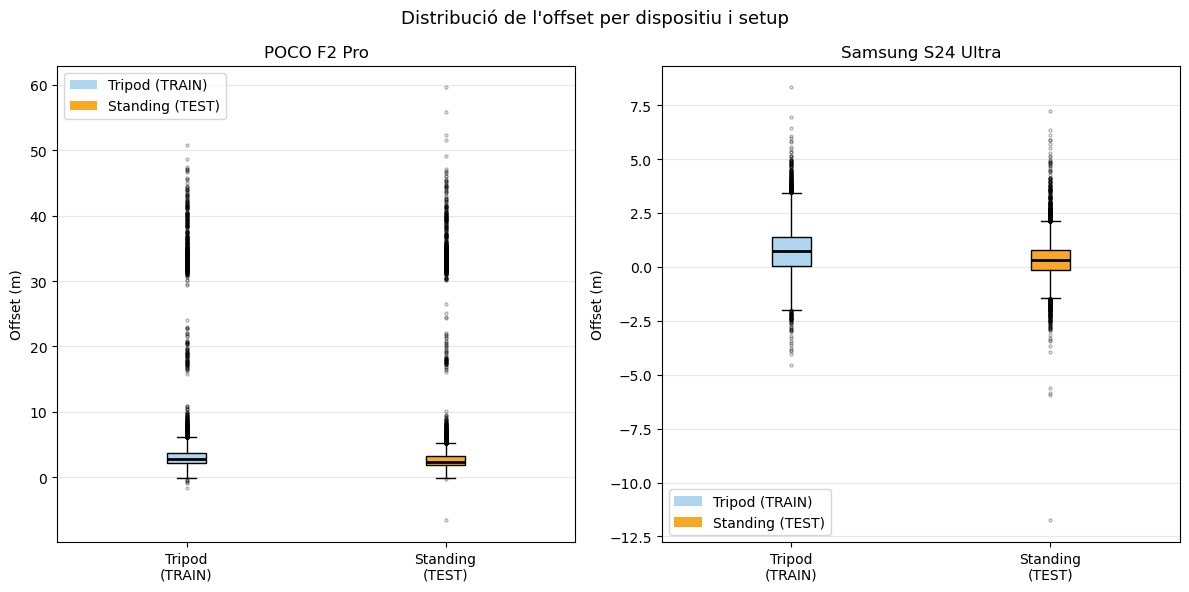

In [121]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Distribució de l'offset per dispositiu i setup", fontsize=13)

legend_elements = [
    Patch(facecolor='#AED6F1', label='Tripod (TRAIN)'),
    Patch(facecolor='#F9A825', label='Standing (TEST)')
]

for ax, (device, label) in zip(axes, [
    ('XiaomiPOCO F2 Pro', 'POCO F2 Pro'),
    ('samsungSM-S928B', 'Samsung S24 Ultra')
]):
    
    subset = df[df['device'] == device]

    data = [
        subset[subset['setup'] == 'tripod']['offset'].dropna(),
        subset[subset['setup'] == 'standing']['offset'].dropna()
    ]

    bp = ax.boxplot(
        data,
        tick_labels=['Tripod\n(TRAIN)', 'Standing\n(TEST)'],
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )

    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#F9A825')

    ax.set_title(label)
    ax.set_ylabel('Offset (m)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('boxplot_offset.png', dpi=150)
plt.show()

El POCO F2 Pro presenta un biaix sistemàtic d'entre 2 i 4 metres, amb outliers que arriben fins als 60 metres, valors físicament impossibles en un laboratori de 14,94 metres de longitud. Aquest fet evidencia un problema greu de fiabilitat en les mesures d'aquest dispositiu. El Samsung S24 Ultra, en canvi, mostra una distribució molt més centrada al voltant de zero, amb outliers que no superen els 12 metres i una variabilitat considerablement inferior.

En ambdós casos, el comportament observat en el setup de trípode (TRAIN) i en el setup standing (TEST) és molt similar, fet que indica que la posició física del dispositiu no constitueix el factor determinant de l'offset. Per tant, les diferències observades entre dispositius es poden atribuir principalment a les característiques de maquinari de cada smartphone i a la seva implementació específica del protocol FTM.

Aquests resultats justifiquen l'aplicació del criteri 3σ com a pas previ a qualsevol tècnica de compensació, especialment en el cas del POCO F2 Pro, on la presència d'outliers extrems podria distorsionar significativament l'estimació de l'offset mitjà.

Amb l'objectiu d'eliminar les observacions anòmales que podrien afectar l'estimació de l'offset, es va aplicar el criteri 3σ sobre les mesures de distància obtingudes per cada dispositiu. Aquest criteri es basa en la hipòtesi que, en una distribució aproximadament normal, la gran majoria de les observacions es troben dins de l'interval definit per la mitjana ± 3 vegades la desviació estàndard.

Per a cada conjunt de dades, es va calcular la mitjana (μ) i la desviació estàndard (σ), eliminant posteriorment totes aquelles mostres que complien:

∣x−μ∣>3σ

Aquest procediment permet reduir la influència dels valors extrems sense alterar significativament el comportament general de la distribució. La seva aplicació és especialment rellevant en el cas del POCO F2 Pro, on s'han observat errors de magnitud molt superior a la distància real del laboratori, indicant la presència de mesures clarament aberrants.

Un cop eliminades les observacions identificades com a outliers, es va tornar a calcular l'offset mitjà de cada dispositiu utilitzant únicament les mostres filtrades. Aquest nou conjunt de dades constitueix la base per als experiments de compensació descrits en els apartats següents.

In [165]:
for device, df_train, df_test in [
    ("POCO F2 Pro",       df_poco_f2_pro_train, df_poco_f2_pro_test),
    ("Samsung S24 Ultra", df_samsung_train,      df_samsung_test),
]:
    for conjunt, df in [("Training (Tripod)", df_train),
                        ("Test (Standing)",   df_test)]:
        errors = df['d_measured'] - df['d_real']
        me   = errors.mean()
        std  = errors.std()
        rmse = np.sqrt((errors**2).mean())
        print(f"{device} | {conjunt} | N={len(errors)} | ME={me:.3f} m | STD={std:.3f} m | RMSE={rmse:.3f} m")

print()
print("--- Després offset ---")
for device, df_test in [
    ("POCO F2 Pro",       df_poco_f2_pro_test),
    ("Samsung S24 Ultra", df_samsung_test),
]:
    errors = df_test['d_correct'] - df_test['d_real']
    me   = errors.mean()
    std  = errors.std()
    rmse = np.sqrt((errors**2).mean())
    print(f"{device} | Test compensat | N={len(errors)} | ME={me:.3f} m | STD={std:.3f} m | RMSE={rmse:.3f} m")

POCO F2 Pro | Training (Tripod) | N=15102 | ME=4.206 m | STD=6.265 m | RMSE=7.546 m
POCO F2 Pro | Test (Standing) | N=15753 | ME=3.950 m | STD=6.668 m | RMSE=7.750 m
Samsung S24 Ultra | Training (Tripod) | N=15409 | ME=0.779 m | STD=1.029 m | RMSE=1.291 m
Samsung S24 Ultra | Test (Standing) | N=15359 | ME=0.367 m | STD=0.797 m | RMSE=0.877 m

--- Després offset ---
POCO F2 Pro | Test compensat | N=15753 | ME=-0.256 m | STD=6.668 m | RMSE=6.673 m
Samsung S24 Ultra | Test compensat | N=15359 | ME=-0.412 m | STD=0.797 m | RMSE=0.897 m


In [124]:
# ── TÈCNICA 2A: Criteri 3σ (només filtratge) ─────────────────

def apply_3sigma(df_train, df_test):
    mu  = df_train['d_measured'].mean()
    sig = df_train['d_measured'].std()
    lim_inf = mu - 3 * sig
    lim_sup = mu + 3 * sig
    
    mask = (df_test['d_measured'] >= lim_inf) & (df_test['d_measured'] <= lim_sup)
    df_filtered = df_test[mask].copy()
    
    n_total   = len(df_test)
    n_filtrat = (~mask).sum()
    print(f"  µ={mu:.4f} m | σ={sig:.4f} m")
    print(f"  Interval vàlid: [{lim_inf:.4f}, {lim_sup:.4f}] m")
    print(f"  Mesures eliminades: {n_filtrat}/{n_total} ({100*n_filtrat/n_total:.1f}%)")
    
    return df_filtered, mu, sig

# POCO F2 Pro
print("── POCO F2 Pro ──")
df_poco_3s, mu_poco, sig_poco = apply_3sigma(df_poco_f2_pro_train, df_poco_f2_pro_test)

errors_abans   = df_poco_f2_pro_test['d_measured'] - df_poco_f2_pro_test['d_real']
errors_despres = df_poco_3s['d_measured']           - df_poco_3s['d_real']

print(f"\n{'':20} {'Abans':>10} {'Després 3σ':>12}")
print(f"{'N mesures':20} {len(df_poco_f2_pro_test):>10} {len(df_poco_3s):>12}")
print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>12.4f}")
print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>12.4f}")
print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>12.4f}")

── POCO F2 Pro ──
  µ=11.9659 m | σ=7.5842 m
  Interval vàlid: [-10.7866, 34.7184] m
  Mesures eliminades: 586/15753 (3.7%)

                          Abans   Després 3σ
N mesures                 15753        15167
ME  (m)                  3.9496       2.7452
RMSE (m)                 7.7496       3.7538
STD  (m)                 6.6679       2.5602


In [125]:
# Samsung S24 Ultra
print("── Samsung S24 Ultra ──")
df_samsung_3s, mu_samsung, sig_samsung = apply_3sigma(df_samsung_train, df_samsung_test)

errors_abans   = df_samsung_test['d_measured'] - df_samsung_test['d_real']
errors_despres = df_samsung_3s['d_measured']   - df_samsung_3s['d_real']

print(f"\n{'':20} {'Abans':>10} {'Després 3σ':>12}")
print(f"{'N mesures':20} {len(df_samsung_test):>10} {len(df_samsung_3s):>12}")
print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>12.4f}")
print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>12.4f}")
print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>12.4f}")

── Samsung S24 Ultra ──
  µ=8.5749 m | σ=4.5301 m
  Interval vàlid: [-5.0155, 22.1653] m
  Mesures eliminades: 0/15359 (0.0%)

                          Abans   Després 3σ
N mesures                 15359        15359
ME  (m)                  0.3668       0.3668
RMSE (m)                 0.8772       0.8772
STD  (m)                 0.7968       0.7968


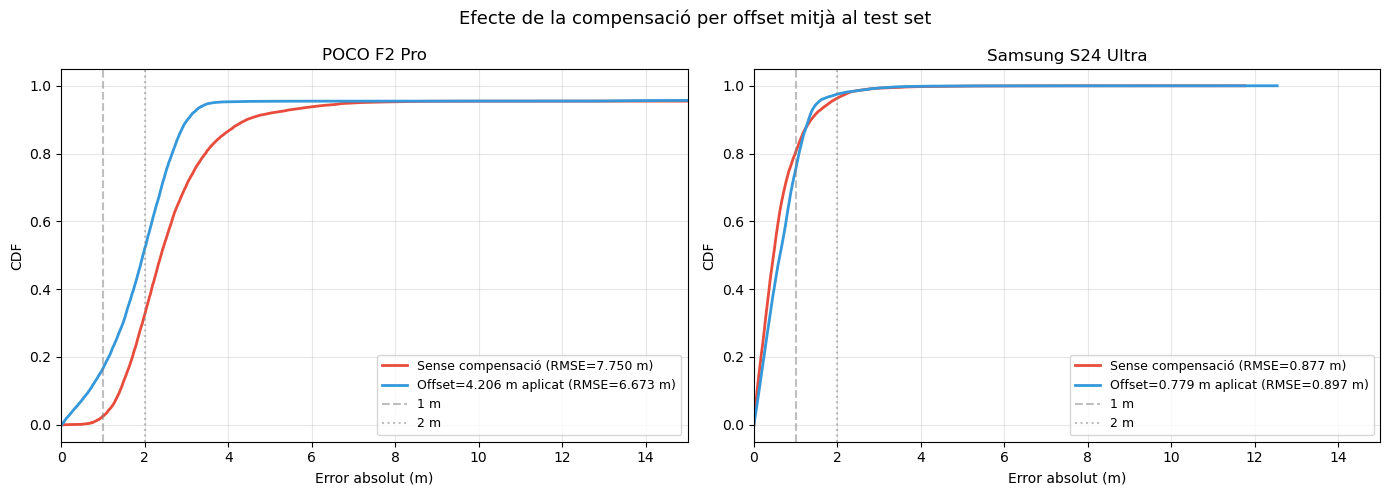

Offset POCO: 4.2060 m
Offset Samsung: 0.7791 m


In [167]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efecte de la compensació per offset mitjà al test set", fontsize=13)

for ax, device, df_te, offset_val in zip(
    axes,
    ["POCO F2 Pro", "Samsung S24 Ultra"],
    [df_poco_f2_pro_test, df_samsung_test],
    [offset_poco, offset_samsung]
):
    before = df_te['d_measured'] - df_te['d_real']
    after  = df_te['d_correct']  - df_te['d_real']
    
    rmse_before = np.sqrt((before**2).mean())
    rmse_after  = np.sqrt((after**2).mean())
    
    for data, label, color in [
        (before, f'Sense compensació (RMSE={rmse_before:.3f} m)', '#e74c3c'),
        (after,  f'Offset={offset_val:.3f} m aplicat (RMSE={rmse_after:.3f} m)', '#3498db'),
    ]:
        sorted_data = np.sort(np.abs(data))
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.plot(sorted_data, cdf, linewidth=2, label=label, color=color)
    
    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='1 m')
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.5, label='2 m')
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(device)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_offset_mitja.png', dpi=150)
plt.show()

print(f"Offset POCO: {offset_poco:.4f} m")
print(f"Offset Samsung: {offset_samsung:.4f} m")

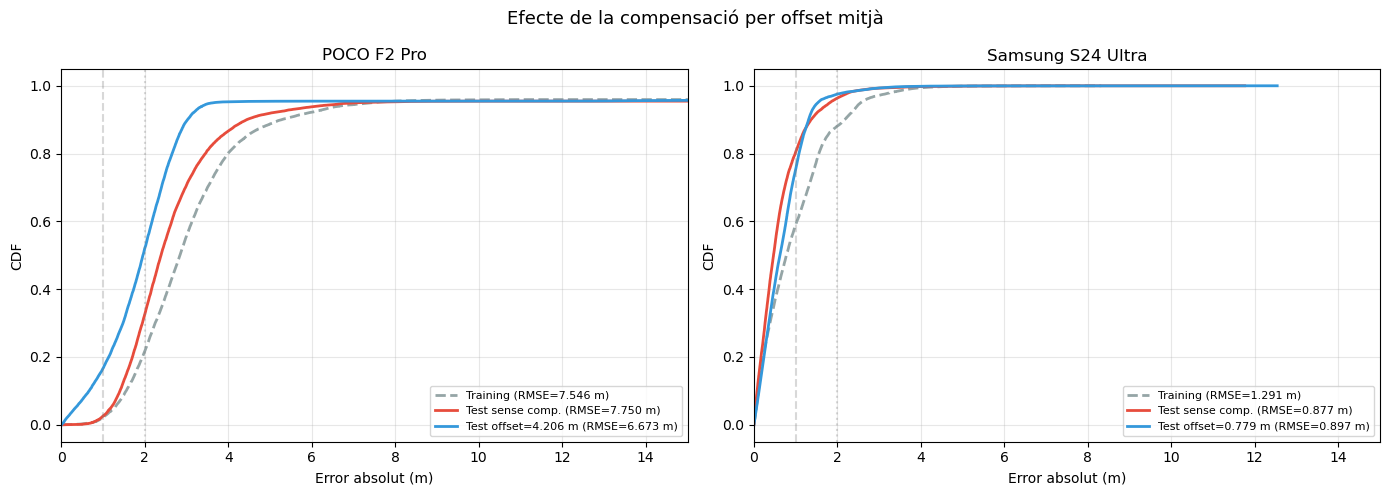

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efecte de la compensació per offset mitjà", fontsize=13)

for ax, device, df_tr, df_te, offset_val in zip(
    axes,
    ["POCO F2 Pro", "Samsung S24 Ultra"],
    [df_poco_f2_pro_train, df_samsung_train],
    [df_poco_f2_pro_test,  df_samsung_test],
    [offset_poco, offset_samsung]
):
    train_err  = df_tr['d_measured'] - df_tr['d_real']
    test_err   = df_te['d_measured'] - df_te['d_real']
    test_corr  = df_te['d_correct']  - df_te['d_real']

    for data, label, color, ls in [
        (train_err, f'Training (RMSE={np.sqrt((train_err**2).mean()):.3f} m)', '#95a5a6', '--'),
        (test_err,  f'Test sense comp. (RMSE={np.sqrt((test_err**2).mean()):.3f} m)', '#e74c3c', '-'),
        (test_corr, f'Test offset={offset_val:.3f} m (RMSE={np.sqrt((test_corr**2).mean()):.3f} m)', '#3498db', '-'),
    ]:
        sorted_data = np.sort(np.abs(data))
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.plot(sorted_data, cdf, linewidth=2, label=label, color=color, linestyle=ls)

    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.3)
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(device)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_offset_mitja.png', dpi=150)
plt.show()

In [161]:
for device, df_train, df_test in [
    ("POCO F2 Pro",       df_poco_f2_pro_train, df_poco_f2_pro_test),
    ("Samsung S24 Ultra", df_samsung_train,      df_samsung_test),
]:
    for conjunt, df in [("Training (Tripod)", df_train), 
                         ("Test (Standing)",   df_test)]:
        errors = df['d_measured'] - df['d_real']
        me   = errors.mean()
        rmse = np.sqrt((errors**2).mean())
        print(f"{device} | {conjunt} | N={len(errors)} | ME={me:.3f} m | RMSE={rmse:.3f} m")

POCO F2 Pro | Training (Tripod) | N=15102 | ME=4.206 m | RMSE=7.546 m
POCO F2 Pro | Test (Standing) | N=15753 | ME=3.950 m | RMSE=7.750 m
Samsung S24 Ultra | Training (Tripod) | N=15409 | ME=0.779 m | RMSE=1.291 m
Samsung S24 Ultra | Test (Standing) | N=15359 | ME=0.367 m | RMSE=0.877 m


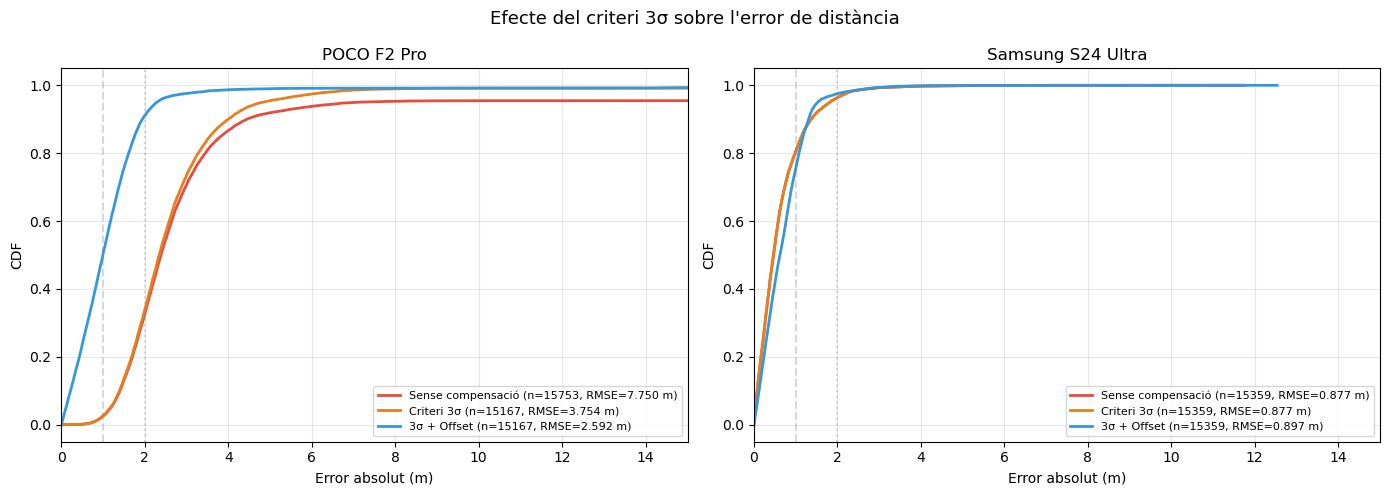

=== VALORS NUMÈRICS ===
POCO F2 Pro | Sense compensació | N=15753 | ME=3.950 m | STD=6.668 m | RMSE=7.750 m
POCO F2 Pro | Criteri 3σ | N=15167 | ME=2.745 m | STD=2.560 m | RMSE=3.754 m
POCO F2 Pro | 3σ + Offset | N=15167 | ME=-0.404 m | STD=2.560 m | RMSE=2.592 m

Samsung S24 Ultra | Sense compensació | N=15359 | ME=0.367 m | STD=0.797 m | RMSE=0.877 m
Samsung S24 Ultra | Criteri 3σ | N=15359 | ME=0.367 m | STD=0.797 m | RMSE=0.877 m
Samsung S24 Ultra | 3σ + Offset | N=15359 | ME=-0.412 m | STD=0.797 m | RMSE=0.897 m



In [171]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efecte del criteri 3σ sobre l'error de distància", fontsize=13)

for ax, device, df_te, df_3s, df_3s_off in zip(
    axes,
    ["POCO F2 Pro", "Samsung S24 Ultra"],
    [df_poco_f2_pro_test, df_samsung_test],
    [df_poco_3s,          df_samsung_3s],
    [df_poco_3s_offset,   df_samsung_3s_offset],
):
    err_before  = df_te['d_measured']  - df_te['d_real']
    err_3s      = df_3s['d_measured']  - df_3s['d_real']
    err_3s_off  = df_3s_off['d_correct'] - df_3s_off['d_real']

    rmse_before = np.sqrt((err_before**2).mean())
    rmse_3s     = np.sqrt((err_3s**2).mean())
    rmse_3s_off = np.sqrt((err_3s_off**2).mean())
    
    n_before = len(err_before)
    n_3s     = len(err_3s)
    n_3s_off = len(err_3s_off)

    for data, label, color in [
        (err_before, f'Sense compensació (n={n_before}, RMSE={rmse_before:.3f} m)', '#e74c3c'),
        (err_3s,     f'Criteri 3σ (n={n_3s}, RMSE={rmse_3s:.3f} m)', '#e67e22'),
        (err_3s_off, f'3σ + Offset (n={n_3s_off}, RMSE={rmse_3s_off:.3f} m)', '#3498db'),
    ]:
        sorted_data = np.sort(np.abs(data))
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.plot(sorted_data, cdf, linewidth=2, label=label, color=color)

    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.3)
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(device)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_3sigma.png', dpi=150)
plt.show()

# Valors numèrics
print("=== VALORS NUMÈRICS ===")
for device, df_te, df_3s, df_3s_off in [
    ("POCO F2 Pro",       df_poco_f2_pro_test, df_poco_3s,     df_poco_3s_offset),
    ("Samsung S24 Ultra", df_samsung_test,      df_samsung_3s,  df_samsung_3s_offset),
]:
    for tecnica, df, col in [
        ("Sense compensació", df_te,      'd_measured'),
        ("Criteri 3σ",        df_3s,      'd_measured'),
        ("3σ + Offset",       df_3s_off,  'd_correct'),
    ]:
        errors = df[col] - df['d_real']
        print(f"{device} | {tecnica} | N={len(errors)} | ME={errors.mean():.3f} m | STD={errors.std():.3f} m | RMSE={np.sqrt((errors**2).mean()):.3f} m")
    print()

In [126]:
# ── TÈCNICA 2B: Criteri 3σ + Offset mitjà ────────────────────
# 1. Filtrem el TRAIN amb 3σ
# 2. Calculem l'offset sobre el TRAIN net
# 3. Filtrem el TEST amb 3σ
# 4. Apliquem l'offset al TEST filtrat

def apply_3sigma_plus_offset(df_train, df_test, device_name):
    # Pas 1+2: filtrar train i calcular offset net
    mu  = df_train['d_measured'].mean()
    sig = df_train['d_measured'].std()
    lim_inf = mu - 3 * sig
    lim_sup = mu + 3 * sig
    
    mask_train   = (df_train['d_measured'] >= lim_inf) & (df_train['d_measured'] <= lim_sup)
    df_train_net = df_train[mask_train].copy()
    offset_net   = (df_train_net['d_measured'] - df_train_net['d_real']).mean()
    print(f"[{device_name}]")
    print(f"  Offset sobre TRAIN net (sense outliers): {offset_net:.4f} m")
    
    # Pas 3+4: filtrar test i aplicar offset
    mask_test   = (df_test['d_measured'] >= lim_inf) & (df_test['d_measured'] <= lim_sup)
    df_test_net = df_test[mask_test].copy()
    df_test_net['d_correct'] = df_test_net['d_measured'] - offset_net
    
    n_total   = len(df_test)
    n_filtrat = (~mask_test).sum()
    print(f"  Mesures eliminades del TEST: {n_filtrat}/{n_total} ({100*n_filtrat/n_total:.1f}%)")
    
    errors_abans   = df_test['d_measured']      - df_test['d_real']
    errors_despres = df_test_net['d_correct']   - df_test_net['d_real']
    
    print(f"\n{'':20} {'Abans':>10} {'3σ+Offset':>12}")
    print(f"{'N mesures':20} {len(df_test):>10} {len(df_test_net):>12}")
    print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>12.4f}")
    print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>12.4f}")
    print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>12.4f}")
    
    return df_test_net, offset_net

df_poco_3s_offset, offset_poco_net       = apply_3sigma_plus_offset(
    df_poco_f2_pro_train, df_poco_f2_pro_test, "POCO F2 Pro")

df_samsung_3s_offset, offset_samsung_net = apply_3sigma_plus_offset(
    df_samsung_train, df_samsung_test, "Samsung S24 Ultra")

[POCO F2 Pro]
  Offset sobre TRAIN net (sense outliers): 3.1490 m
  Mesures eliminades del TEST: 586/15753 (3.7%)

                          Abans    3σ+Offset
N mesures                 15753        15167
ME  (m)                  3.9496      -0.4038
RMSE (m)                 7.7496       2.5918
STD  (m)                 6.6679       2.5602
[Samsung S24 Ultra]
  Offset sobre TRAIN net (sense outliers): 0.7791 m
  Mesures eliminades del TEST: 0/15359 (0.0%)

                          Abans    3σ+Offset
N mesures                 15359        15359
ME  (m)                  0.3668      -0.4124
RMSE (m)                 0.8772       0.8972
STD  (m)                 0.7968       0.7968


La combinació aconsegueix el que cap tècnica sola podia: eliminar els outliers (3σ) i corregir el biaix residual (offset). El RMSE passa de 7,75 m a 2,59 m, una reducció del 66% respecte a les mesures brutes.
El Samsung pràcticament no es beneficia de cap de les dues primeres tècniques. Això és una conclusió molt important per al TFG perquè demostra que la necessitat de compensació depèn críticament del dispositiu. Un Samsung S24 Ultra ja funciona prou bé sense cap tractament (RMSE de 0,88 m), mentre que el POCO F2 Pro sense tractament és inutilitzable (RMSE de 7,75 m)

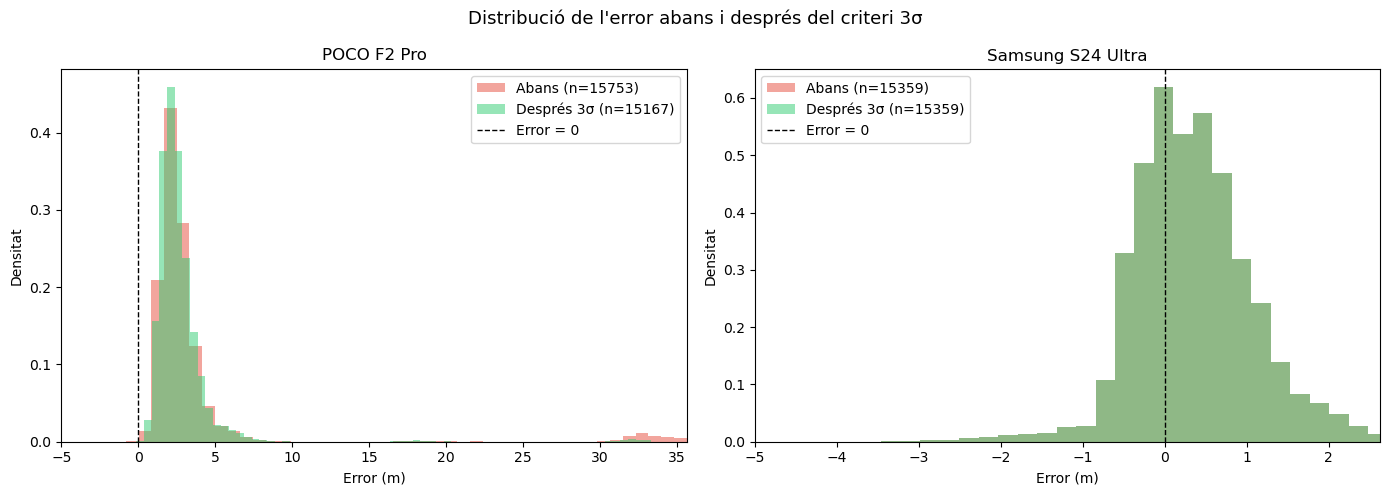

In [128]:
# ── GRÀFICA 1: Histograma de l'error abans/després del 3σ ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribució de l'error abans i després del criteri 3σ", fontsize=13)

for ax, (device_name, df_test, df_3s) in zip(axes, [
    ("POCO F2 Pro",       df_poco_f2_pro_test, df_poco_3s),
    ("Samsung S24 Ultra", df_samsung_test,     df_samsung_3s),
]):
    errors_abans   = df_test['d_measured'] - df_test['d_real']
    errors_despres = df_3s['d_measured']   - df_3s['d_real']

    # Limitem l'eix x per fer-lo llegible (outliers extrems distorsionen)
    lim = errors_abans.quantile(0.99)

    ax.hist(errors_abans,   bins=80, alpha=0.5, color='#E74C3C',
            label=f'Abans (n={len(errors_abans)})',   density=True)
    ax.hist(errors_despres, bins=80, alpha=0.5, color='#2ECC71',
            label=f'Després 3σ (n={len(errors_despres)})', density=True)

    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Error = 0')
    ax.set_xlim(-5, lim)
    ax.set_title(device_name)
    ax.set_xlabel('Error (m)')
    ax.set_ylabel('Densitat')
    ax.legend()

plt.tight_layout()
plt.savefig('histograma_3sigma.png', dpi=150)
plt.show()

In [157]:
# Veure quines variables tenim definides relacionades amb poco i samsung
import pandas as pd
print([v for v in dir() if 'poco' in v.lower() or 'samsung' in v.lower() or 'df_' in v.lower()])
print(df_poco_f2_pro_test.columns.tolist())

['df_3s', 'df_3s_off', 'df_aps', 'df_kal', 'df_kal_3s', 'df_kal_brut', 'df_loc', 'df_new', 'df_poco_3s', 'df_poco_3s_offset', 'df_poco_f2_pro', 'df_poco_f2_pro_test', 'df_poco_f2_pro_train', 'df_poco_kalman_3s', 'df_poco_kalman_brut', 'df_poco_triple', 'df_samsung', 'df_samsung_3s', 'df_samsung_3s_offset', 'df_samsung_kalman_3s', 'df_samsung_kalman_brut', 'df_samsung_test', 'df_samsung_train', 'df_samsung_triple', 'df_test', 'df_triple', 'errors_poco_after', 'errors_poco_before', 'errors_samsung_after', 'errors_samsung_before', 'mu_poco', 'mu_samsung', 'offset_poco', 'offset_poco_net', 'offset_poco_triple', 'offset_samsung', 'offset_samsung_net', 'offset_samsung_triple', 'sig_poco', 'sig_samsung']
['device', 'setup', 'point_id', 'x_true', 'y_true', 'ap_mac', 'ap_x', 'ap_y', 'd_real', 'd_measured', 'std_mm', 'timestamp', 'offset', 'd_correct']


POCO abans: 15753 | després: 15167
Samsung abans: 15359 | després: 15359


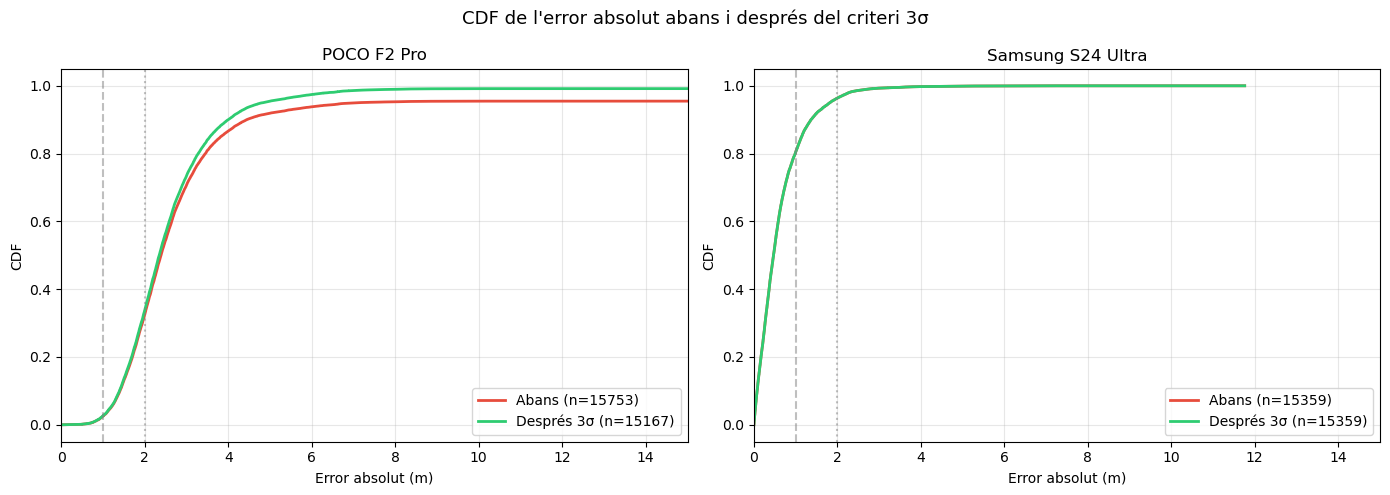

In [155]:
# Errors abans i després del 3σ
errors_poco_before   = df_poco_f2_pro_test['d_measured'] - df_poco_f2_pro_test['d_real']
errors_poco_after    = df_poco_3s['d_measured'] - df_poco_3s['d_real']

errors_samsung_before = df_samsung_test['d_measured'] - df_samsung_test['d_real']
errors_samsung_after  = df_samsung_3s['d_measured'] - df_samsung_3s['d_real']

print(f"POCO abans: {len(errors_poco_before)} | després: {len(errors_poco_after)}")
print(f"Samsung abans: {len(errors_samsung_before)} | després: {len(errors_samsung_after)}")

# CDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CDF de l'error absolut abans i després del criteri 3σ", fontsize=13)

for ax, device, before, after in zip(
    axes,
    ["POCO F2 Pro", "Samsung S24 Ultra"],
    [errors_poco_before, errors_samsung_before],
    [errors_poco_after,  errors_samsung_after]
):
    for data, label, color in [
        (before, f'Abans (n={len(before)})', '#e74c3c'),
        (after,  f'Després 3σ (n={len(after)})', '#2ecc71'),
    ]:
        sorted_data = np.sort(np.abs(data))
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.plot(sorted_data, cdf, label=label, color=color, linewidth=2)

    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(device)
    ax.legend()
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_3sigma.png', dpi=150)
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_14228\2833213705.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
C:\Users\franc\AppData\Local\Temp\ipykernel_14228\2833213705.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


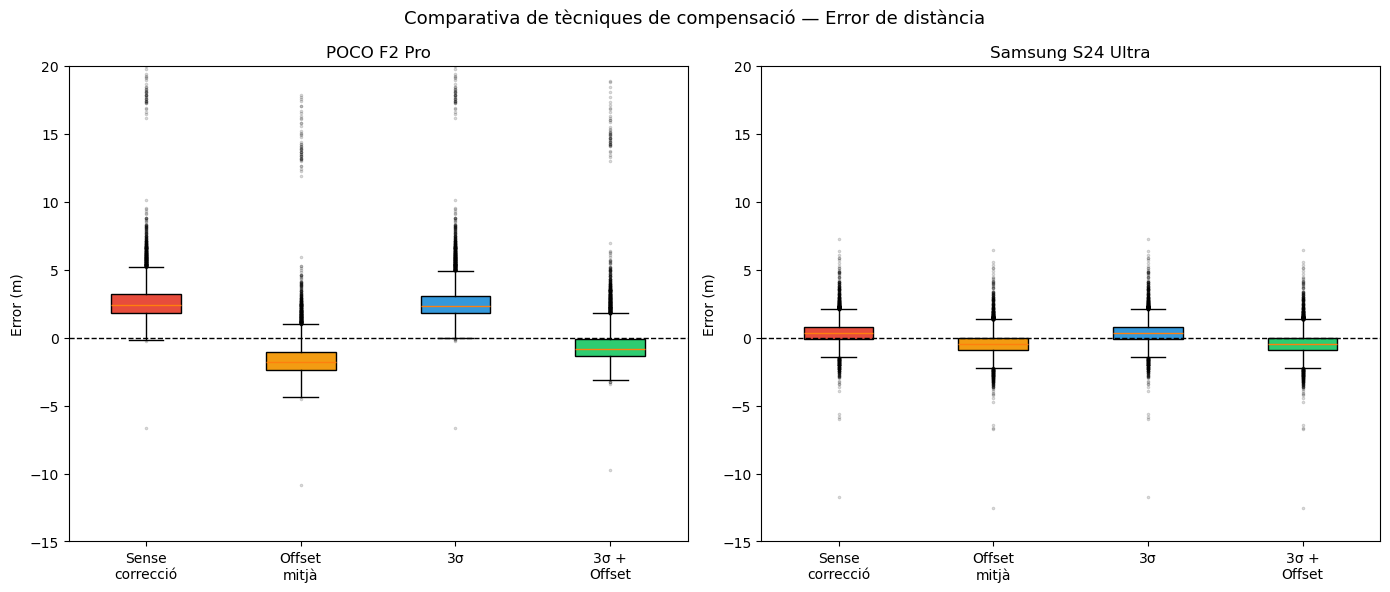

In [39]:
# ── GRÀFICA 2: Boxplot comparatiu de totes les tècniques ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparativa de tècniques de compensació — Error de distància", fontsize=13)

for ax, (device_name, df_test, df_3s, df_3s_off, offset) in zip(axes, [
    ("POCO F2 Pro",
     df_poco_f2_pro_test, df_poco_3s, df_poco_3s_offset, offset_poco),
    ("Samsung S24 Ultra",
     df_samsung_test, df_samsung_3s, df_samsung_3s_offset, offset_samsung),
]):
    # Calculem els errors de cada tècnica
    e_raw    = df_test['d_measured']              - df_test['d_real']
    e_offset = (df_test['d_measured'] - offset)   - df_test['d_real']
    e_3s     = df_3s['d_measured']                - df_3s['d_real']
    e_3s_off = df_3s_off['d_correct']             - df_3s_off['d_real']

    data   = [e_raw, e_offset, e_3s, e_3s_off]
    labels = ['Sense\ncorrecció', 'Offset\nmitjà', '3σ', '3σ +\nOffset']
    colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']

    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    showfliers=True,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.2))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(device_name)
    ax.set_ylabel('Error (m)')
    ax.set_ylim(-15, 20)  # ajusta si cal

plt.tight_layout()
plt.savefig('boxplot_comparatiu.png', dpi=150)
plt.show()

In [40]:
# ── TÈCNICA 3: Filtre de Kalman ───────────────────────────────

def kalman_1d(mesures, q=0.01, r=1.0):
    """
    Filtre de Kalman 1D sobre una seqüència de distàncies.
    q: soroll del procés (quant canvia la distància real entre mesures)
    r: soroll de la mesura (variabilitat del sensor)
    """
    x = mesures[0]  # estimació inicial = primera mesura
    p = 1.0          # incertesa inicial
    filtrades = []

    for z in mesures:
        p = p + q                  # predicció
        k = p / (p + r)            # guany de Kalman
        x = x + k * (z - x)       # actualització
        p = (1 - k) * p            # incertesa actualitzada
        filtrades.append(x)

    return np.array(filtrades)


def apply_kalman(df_test, device_name, q=0.01, r=1.0):
    df_out = []
    for (pt, mac), grp in df_test.groupby(['point_id', 'ap_mac']):
        grp = grp.copy().sort_values('timestamp')
        grp['d_kalman'] = kalman_1d(grp['d_measured'].values, q=q, r=r)
        df_out.append(grp)
    return pd.concat(df_out)

In [41]:
# ── 3A: Kalman sobre mesures BRUTES ──────────────────────────

# Paràmetres: r alt per al POCO (molt sorollós), r baix per al Samsung
df_poco_kalman_brut    = apply_kalman(df_poco_f2_pro_test,  "POCO F2 Pro",       q=0.01, r=5.0)
df_samsung_kalman_brut = apply_kalman(df_samsung_test, "Samsung S24 Ultra",  q=0.01, r=0.8)

for device_name, df_test, df_kal in [
    ("POCO F2 Pro",       df_poco_f2_pro_test, df_poco_kalman_brut),
    ("Samsung S24 Ultra", df_samsung_test,     df_samsung_kalman_brut),
]:
    errors_abans   = df_test['d_measured'] - df_test['d_real']
    errors_despres = df_kal['d_kalman']    - df_kal['d_real']

    print(f"\n── {device_name} (Kalman sobre brutes) ──")
    print(f"{'':20} {'Abans':>10} {'Kalman':>10}")
    print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>10.4f}")
    print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>10.4f}")
    print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>10.4f}")


── POCO F2 Pro (Kalman sobre brutes) ──
                          Abans     Kalman
ME  (m)                  3.9496     3.9495
RMSE (m)                 7.7496     4.4016
STD  (m)                 6.6679     1.9432

── Samsung S24 Ultra (Kalman sobre brutes) ──
                          Abans     Kalman
ME  (m)                  0.3668     0.3417
RMSE (m)                 0.8772     0.7573
STD  (m)                 0.7968     0.6759


In [42]:
# ── 3B: Kalman sobre mesures FILTRADES amb 3σ ────────────────

df_poco_kalman_3s    = apply_kalman(df_poco_3s,    "POCO F2 Pro",       q=0.01, r=5.0)
df_samsung_kalman_3s = apply_kalman(df_samsung_3s, "Samsung S24 Ultra", q=0.01, r=0.8)

for device_name, df_3s, df_kal in [
    ("POCO F2 Pro",       df_poco_3s,    df_poco_kalman_3s),
    ("Samsung S24 Ultra", df_samsung_3s, df_samsung_kalman_3s),
]:
    errors_abans   = df_3s['d_measured'] - df_3s['d_real']
    errors_despres = df_kal['d_kalman']  - df_kal['d_real']

    print(f"\n── {device_name} (Kalman sobre 3σ) ──")
    print(f"{'':20} {'Abans 3σ':>10} {'3σ+Kalman':>12}")
    print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>12.4f}")
    print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>12.4f}")
    print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>12.4f}")


── POCO F2 Pro (Kalman sobre 3σ) ──
                       Abans 3σ    3σ+Kalman
ME  (m)                  2.7452       2.7788
RMSE (m)                 3.7538       3.0394
STD  (m)                 2.5602       1.2314

── Samsung S24 Ultra (Kalman sobre 3σ) ──
                       Abans 3σ    3σ+Kalman
ME  (m)                  0.3668       0.3417
RMSE (m)                 0.8772       0.7573
STD  (m)                 0.7968       0.6759


In [43]:
# ── TÈCNICA 4: 3σ + Offset + Kalman ──────────────────────────

def apply_3sigma_offset_kalman(df_train, df_test, device_name, q=0.01, r=1.0):
    
    # PAS 1: Filtrar TRAIN amb 3σ i calcular offset net
    mu  = df_train['d_measured'].mean()
    sig = df_train['d_measured'].std()
    lim_inf = mu - 3 * sig
    lim_sup = mu + 3 * sig

    mask_train   = (df_train['d_measured'] >= lim_inf) & (df_train['d_measured'] <= lim_sup)
    df_train_net = df_train[mask_train].copy()
    offset_net   = (df_train_net['d_measured'] - df_train_net['d_real']).mean()

    print(f"[{device_name}]")
    print(f"  Interval 3σ: [{lim_inf:.4f}, {lim_sup:.4f}] m")
    print(f"  Offset net (train sense outliers): {offset_net:.4f} m")

    # PAS 2: Filtrar TEST amb 3σ
    mask_test   = (df_test['d_measured'] >= lim_inf) & (df_test['d_measured'] <= lim_sup)
    df_test_net = df_test[mask_test].copy()
    n_filtrat   = (~mask_test).sum()
    print(f"  Mesures eliminades del TEST: {n_filtrat}/{len(df_test)} ({100*n_filtrat/len(df_test):.1f}%)")

    # PAS 3: Aplicar offset
    df_test_net['d_offset'] = df_test_net['d_measured'] - offset_net

    # PAS 4: Aplicar Kalman sobre les mesures ja corregides per offset
    df_out = []
    for (pt, mac), grp in df_test_net.groupby(['point_id', 'ap_mac']):
        grp = grp.copy().sort_values('timestamp')
        grp['d_kalman'] = kalman_1d(grp['d_offset'].values, q=q, r=r)
        df_out.append(grp)
    df_out = pd.concat(df_out)

    # AVALUACIÓ
    errors_abans   = df_test['d_measured']   - df_test['d_real']
    errors_despres = df_out['d_kalman']       - df_out['d_real']

    print(f"\n{'':20} {'Abans':>10} {'3σ+Off+Kal':>12}")
    print(f"{'N mesures':20} {len(df_test):>10} {len(df_out):>12}")
    print(f"{'ME  (m)':20} {errors_abans.mean():>10.4f} {errors_despres.mean():>12.4f}")
    print(f"{'RMSE (m)':20} {np.sqrt((errors_abans**2).mean()):>10.4f} {np.sqrt((errors_despres**2).mean()):>12.4f}")
    print(f"{'STD  (m)':20} {errors_abans.std():>10.4f} {errors_despres.std():>12.4f}")

    return df_out, offset_net

In [44]:
# POCO F2 Pro
df_poco_triple, offset_poco_triple = apply_3sigma_offset_kalman(
    df_poco_f2_pro_train,
    df_poco_f2_pro_test,
    "POCO F2 Pro",
    q=0.01, r=5.0
)

[POCO F2 Pro]
  Interval 3σ: [-10.7866, 34.7184] m
  Offset net (train sense outliers): 3.1490 m
  Mesures eliminades del TEST: 586/15753 (3.7%)

                          Abans   3σ+Off+Kal
N mesures                 15753        15167
ME  (m)                  3.9496      -0.3702
RMSE (m)                 7.7496       1.2858
STD  (m)                 6.6679       1.2314


In [45]:
# Samsung S24 Ultra
df_samsung_triple, offset_samsung_triple = apply_3sigma_offset_kalman(
    df_samsung_train,
    df_samsung_test,
    "Samsung S24 Ultra",
    q=0.01, r=0.8
)

[Samsung S24 Ultra]
  Interval 3σ: [-5.0155, 22.1653] m
  Offset net (train sense outliers): 0.7791 m
  Mesures eliminades del TEST: 0/15359 (0.0%)

                          Abans   3σ+Off+Kal
N mesures                 15359        15359
ME  (m)                  0.3668      -0.4374
RMSE (m)                 0.8772       0.8050
STD  (m)                 0.7968       0.6759


Les conclusions finals són molt clares. Per al POCO F2 Pro la triple combinació 3σ+Offset+Kalman és incontestablement la millor. Per al Samsung el Kalman sol o 3σ+Kalman donen el millor RMSE (0.76 m), i afegir l'offset no millora sinó que lleugerament empitjora perquè el biaix del Samsung és tan petit que la correcció introdueix més error del que elimina.

POCO F2 Pro — resultat espectacular:
El RMSE passa de 7.75 m a 1.29 m, una reducció del 83% respecte a les mesures brutes. És amb diferència el millor resultat obtingut. La STD de 1.23 m és la més baixa de totes les tècniques i el ME de -0.37 m indica que el biaix està pràcticament eliminat.
Samsung S24 Ultra — millora modesta però consistent:
El RMSE passa de 0.88 m a 0.81 m. No és una millora espectacular però és la millor que hem aconseguit amb aquest dispositiu.

In [77]:
import pandas as pd

resultats = []

for device_name, df_test, df_3s, df_3s_off, df_kal_brut, df_kal_3s, df_triple, offset in [
    ("POCO F2 Pro", df_poco_f2_pro_test, df_poco_3s, df_poco_3s_offset, 
     df_poco_kalman_brut, df_poco_kalman_3s, df_poco_triple, offset_poco),
    ("Samsung S24 Ultra", df_samsung_test, df_samsung_3s, df_samsung_3s_offset,
     df_samsung_kalman_brut, df_samsung_kalman_3s, df_samsung_triple, offset_samsung),
]:
    def row(tecnica, errors):
        return {"Dispositiu": device_name, "Tècnica": tecnica,
                "N": len(errors), "ME": round(errors.mean(),4), 
                "RMSE": round((errors**2).mean()**0.5, 4)}
    
    resultats += [
        row("Sense compensació", df_test['d_measured'] - df_test['d_real']),
        row("Offset mitjà", df_test['d_correct'] - df_test['d_real']),
        row("3σ", df_3s['d_measured'] - df_3s['d_real']),
        row("3σ + Offset", df_3s_off['d_correct'] - df_3s_off['d_real']),
        row("Kalman brut", df_kal_brut['d_kalman'] - df_kal_brut['d_real']),
        row("Kalman + 3σ", df_kal_3s['d_kalman'] - df_kal_3s['d_real']),
        row("3σ + Offset + Kalman", df_triple['d_kalman'] - df_triple['d_real']),
    ]

pd.DataFrame(resultats)

,Dispositiu,Tècnica,N,ME,RMSE
0,POCO F2 Pro,Sense compensació,15753,3.9496,7.7496
1,POCO F2 Pro,Offset mitjà,15753,-0.2564,6.6726
2,POCO F2 Pro,3σ,15167,2.7452,3.7538
3,POCO F2 Pro,3σ + Offset,15167,-0.4038,2.5918
4,POCO F2 Pro,Kalman brut,15753,3.9495,4.4016
5,POCO F2 Pro,Kalman + 3σ,15167,2.7788,3.0394
6,POCO F2 Pro,3σ + Offset + Kalman,15167,-0.3702,1.2858
7,Samsung S24 Ultra,Sense compensació,15359,0.3668,0.8772
8,Samsung S24 Ultra,Offset mitjà,15359,-0.4124,0.8972
9,Samsung S24 Ultra,3σ,15359,0.3668,0.8772


C:\Users\franc\AppData\Local\Temp\ipykernel_14228\3498527035.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True,
C:\Users\franc\AppData\Local\Temp\ipykernel_14228\3498527035.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True,


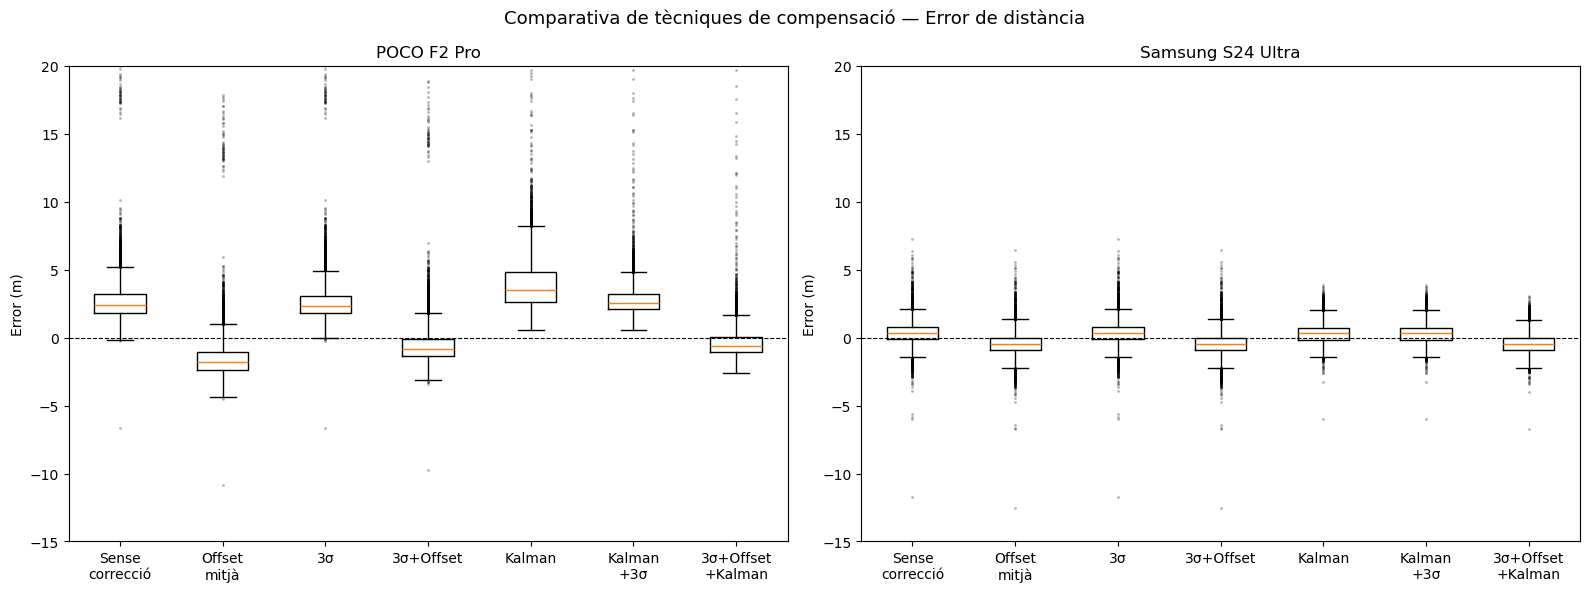

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparativa de tècniques de compensació — Error de distància", fontsize=13)

for ax, (device_name, df_test, df_3s, df_3s_off, df_kal_brut, df_kal_3s, df_triple) in zip(axes, [
    ("POCO F2 Pro", df_poco_f2_pro_test, df_poco_3s, df_poco_3s_offset,
     df_poco_kalman_brut, df_poco_kalman_3s, df_poco_triple),
    ("Samsung S24 Ultra", df_samsung_test, df_samsung_3s, df_samsung_3s_offset,
     df_samsung_kalman_brut, df_samsung_kalman_3s, df_samsung_triple),
]):
    data = [
        df_test['d_measured'] - df_test['d_real'],
        df_test['d_correct'] - df_test['d_real'],
        df_3s['d_measured'] - df_3s['d_real'],
        df_3s_off['d_correct'] - df_3s_off['d_real'],
        df_kal_brut['d_kalman'] - df_kal_brut['d_real'],
        df_kal_3s['d_kalman'] - df_kal_3s['d_real'],
        df_triple['d_kalman'] - df_triple['d_real'],
    ]
    labels = ['Sense\ncorrecció', 'Offset\nmitjà', '3σ', '3σ+Offset',
              'Kalman', 'Kalman\n+3σ', '3σ+Offset\n+Kalman']
    
    ax.boxplot(data, labels=labels, showfliers=True,
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(device_name)
    ax.set_ylabel('Error (m)')
    ax.set_ylim(-15, 20)

plt.tight_layout()
plt.savefig('comparativa_completa.png', dpi=150)
plt.show()

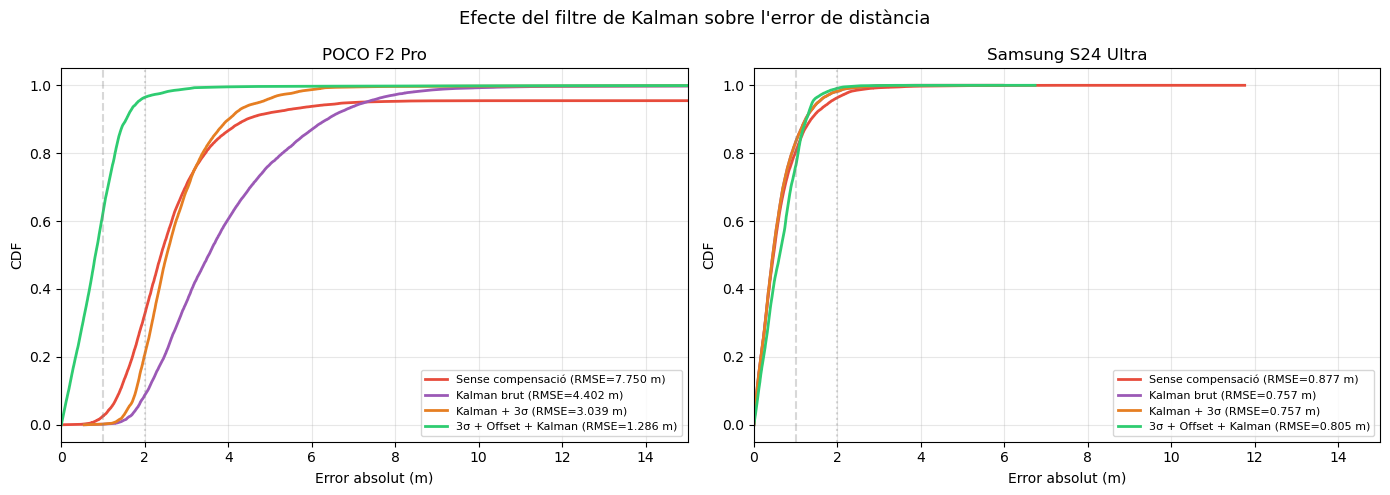

=== VALORS NUMÈRICS ===
POCO F2 Pro | Sense compensació | N=15753 | ME=3.950 m | STD=6.668 m | RMSE=7.750 m
POCO F2 Pro | Kalman brut | N=15753 | ME=3.949 m | STD=1.943 m | RMSE=4.402 m
POCO F2 Pro | Kalman + 3σ | N=15167 | ME=2.779 m | STD=1.231 m | RMSE=3.039 m
POCO F2 Pro | 3σ + Offset + Kalman | N=15167 | ME=-0.370 m | STD=1.231 m | RMSE=1.286 m

Samsung S24 Ultra | Sense compensació | N=15359 | ME=0.367 m | STD=0.797 m | RMSE=0.877 m
Samsung S24 Ultra | Kalman brut | N=15359 | ME=0.342 m | STD=0.676 m | RMSE=0.757 m
Samsung S24 Ultra | Kalman + 3σ | N=15359 | ME=0.342 m | STD=0.676 m | RMSE=0.757 m
Samsung S24 Ultra | 3σ + Offset + Kalman | N=15359 | ME=-0.437 m | STD=0.676 m | RMSE=0.805 m



In [173]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efecte del filtre de Kalman sobre l'error de distància", fontsize=13)

for ax, device, df_te, df_kal_brut, df_kal_3s, df_triple in zip(
    axes,
    ["POCO F2 Pro", "Samsung S24 Ultra"],
    [df_poco_f2_pro_test, df_samsung_test],
    [df_poco_kalman_brut, df_samsung_kalman_brut],
    [df_poco_kalman_3s,   df_samsung_kalman_3s],
    [df_poco_triple,      df_samsung_triple],
):
    err_before   = df_te['d_measured']    - df_te['d_real']
    err_kal_brut = df_kal_brut['d_kalman'] - df_kal_brut['d_real']
    err_kal_3s   = df_kal_3s['d_kalman']   - df_kal_3s['d_real']
    err_triple   = df_triple['d_kalman']   - df_triple['d_real']

    for data, label, color in [
        (err_before,   f'Sense compensació (RMSE={np.sqrt((err_before**2).mean()):.3f} m)',   '#e74c3c'),
        (err_kal_brut, f'Kalman brut (RMSE={np.sqrt((err_kal_brut**2).mean()):.3f} m)',       '#9b59b6'),
        (err_kal_3s,   f'Kalman + 3σ (RMSE={np.sqrt((err_kal_3s**2).mean()):.3f} m)',         '#e67e22'),
        (err_triple,   f'3σ + Offset + Kalman (RMSE={np.sqrt((err_triple**2).mean()):.3f} m)','#2ecc71'),
    ]:
        sorted_data = np.sort(np.abs(data))
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.plot(sorted_data, cdf, linewidth=2, label=label, color=color)

    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.3)
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(device)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_kalman.png', dpi=150)
plt.show()

# Valors numèrics
print("=== VALORS NUMÈRICS ===")
for device, df_te, df_kal_brut, df_kal_3s, df_triple in [
    ("POCO F2 Pro",       df_poco_f2_pro_test, df_poco_kalman_brut,    df_poco_kalman_3s,    df_poco_triple),
    ("Samsung S24 Ultra", df_samsung_test,      df_samsung_kalman_brut, df_samsung_kalman_3s, df_samsung_triple),
]:
    for tecnica, df, col in [
        ("Sense compensació",   df_te,        'd_measured'),
        ("Kalman brut",         df_kal_brut,  'd_kalman'),
        ("Kalman + 3σ",         df_kal_3s,    'd_kalman'),
        ("3σ + Offset + Kalman",df_triple,    'd_kalman'),
    ]:
        errors = df[col] - df['d_real']
        print(f"{device} | {tecnica} | N={len(errors)} | ME={errors.mean():.3f} m | STD={errors.std():.3f} m | RMSE={np.sqrt((errors**2).mean()):.3f} m")
    print()

In [175]:
print("=== OFFSET SISTEMÀTIC DATASET 2 (UVIndoorLoc) ===\n")

for device in ['POCO', 'GP10', 'S24U']:
    df_dev = df_train[df_train['smartphone'] == device]
    errors_all = []
    
    for ap_id in AP_IDS:
        col_meas = f'dist_ap{ap_id}'
        col_real = f'd_real_ap{ap_id}'
        mask = df_dev[col_meas] != MISSING
        if mask.sum() > 0:
            errs = (df_dev.loc[mask, col_meas] - df_dev.loc[mask, col_real])
            errors_all.append(errs)
    
    if errors_all:
        all_e = pd.concat(errors_all)
        print(f"{device}:")
        print(f"  N      = {len(all_e)}")
        print(f"  ME     = {all_e.mean():.1f} mm = {all_e.mean()/1000:.4f} m")
        print(f"  STD    = {all_e.std():.1f} mm = {all_e.std()/1000:.4f} m")
        print(f"  RMSE   = {(all_e**2).mean()**0.5:.1f} mm = {(all_e**2).mean()**0.5/1000:.4f} m")
        print()

=== OFFSET SISTEMÀTIC DATASET 2 (UVIndoorLoc) ===



KeyError: 'smartphone'

In [177]:
print(df_train.columns.tolist())
print()
print(df_train.head(2).to_string())

['device', 'setup', 'point_id', 'x_true', 'y_true', 'ap_mac', 'ap_x', 'ap_y', 'd_real', 'd_measured', 'std_mm', 'timestamp', 'offset']

                device   setup point_id  x_true  y_true             ap_mac  ap_x    ap_y   d_real  d_measured  std_mm   timestamp  offset
30855  samsungSM-S928B  tripod      p01   1.185   0.515  90:ca:fa:8b:13:b4  4.10   1.107   2.9745       0.685    25.0  88167359.0 -2.2895
30856  samsungSM-S928B  tripod      p01   1.185   0.515  24:e5:0f:2c:ff:15  4.83  14.656  14.6032      14.109   352.0  88167358.0 -0.4942


In [195]:
base_path = r"C:\Users\franc\Downloads\UVIndoorLoc-RTT&RSSI"
df_aps_d2 = pd.read_csv(base_path + r'\00_aps.csv')
df_loc = pd.read_csv(base_path +r'\00_locations.csv')
df_train = pd.read_csv(base_path +r'\01_training.csv')
df_test1_d2 = pd.read_csv(base_path + r'\02_test1.csv')   # test mateix dia
df_test2_d2 = pd.read_csv(base_path +r'\02_test2.csv')   # test dia diferent
AP_IDS = list(range(1, 21))  # 20 APs al dataset 2
MISSING = -1000000  # valor missing en mm

In [199]:
# Calcular d_real en mm
def calcular_d_real_d2(df, df_aps):
    df = df.copy()
    for _, ap in df_aps.iterrows():
        ap_id    = int(ap['id'])
        col_real = f'd_real_ap{ap_id}'
        dx = (df['x'] - ap['x']) * 1000
        dy = (df['y'] - ap['y']) * 1000
        dz = (df['z'] - ap['z']) * 1000
        df[col_real] = np.sqrt(dx**2 + dy**2 + dz**2)
    return df

df_test1_d2 = calcular_d_real_d2(df_test1_d2, df_aps_d2)

print(f"Dataset 2 carregat: {len(df_test1_d2)} files")
print(f"Dispositius: {df_test1_d2['smartphone'].unique()}")
print(f"d_real_ap1 primera fila: {df_test1_d2['d_real_ap1'].iloc[0]:.1f} mm")

Dataset 2 carregat: 66698 files
Dispositius: ['GP10' 'S24U' 'POCO']
d_real_ap1 primera fila: 14715.5 mm


In [203]:
# CEL·LA 2: Errors per dispositiu Dataset 2
errors_d2 = {}
for device in ['POCO', 'GP10', 'S24U']:
    df_dev = df_test1_d2[df_test1_d2['smartphone'] == device]
    errors_all = []
    for ap_id in AP_IDS_D2:
        col_meas = f'dist_ap{ap_id}'
        col_real = f'd_real_ap{ap_id}'
        mask = df_dev[col_meas] != MISSING_D2
        if mask.sum() > 0:
            errs = (df_dev.loc[mask, col_meas] - df_dev.loc[mask, col_real]) / 1000
            errors_all.append(errs)
    if errors_all:
        errors_d2[device] = pd.concat(errors_all)
        print(f"{device}: N={len(errors_d2[device])} | ME={errors_d2[device].mean():.3f} m | RMSE={(errors_d2[device]**2).mean()**0.5:.3f} m")

POCO: N=228012 | ME=0.133 m | RMSE=2.165 m
GP10: N=62666 | ME=1.565 m | RMSE=5.141 m
S24U: N=148235 | ME=1.321 m | RMSE=3.178 m


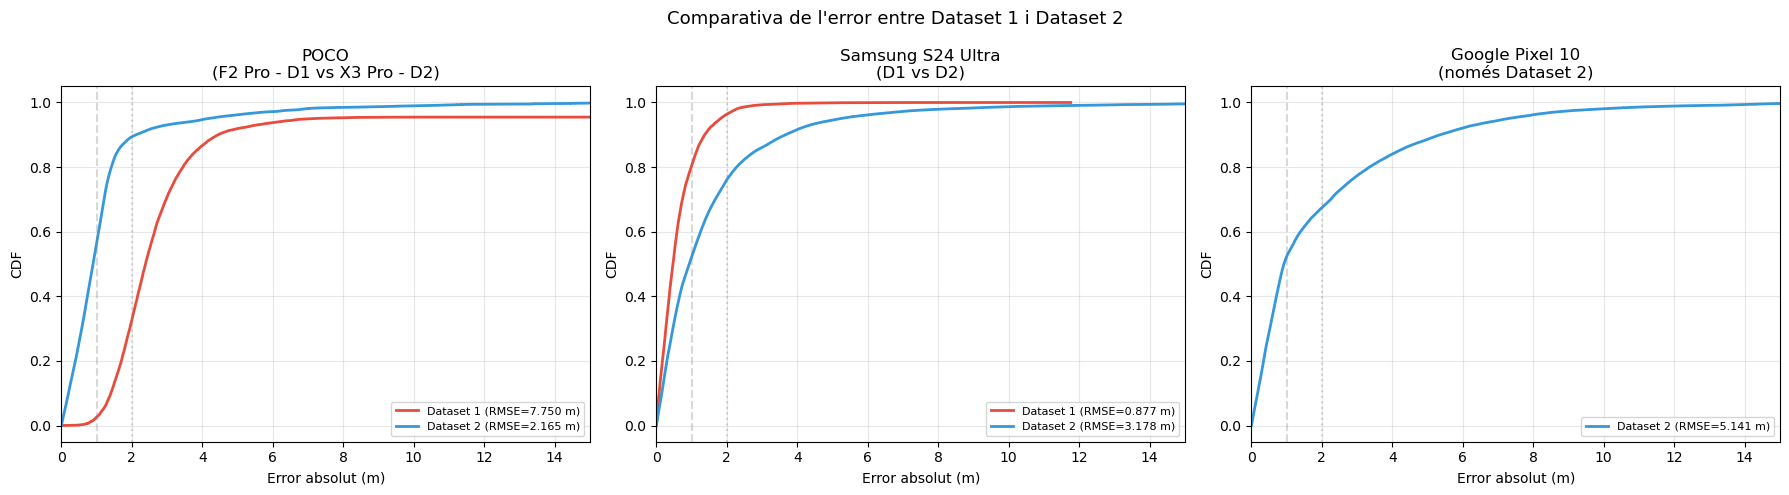

In [205]:
# CEL·LA 3: Gràfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparativa de l'error entre Dataset 1 i Dataset 2", fontsize=13)

# Errors Dataset 1 ja calculats
errors_d1 = {
    'POCO': df_poco_f2_pro_test['d_measured'] - df_poco_f2_pro_test['d_real'],
    'S24U': df_samsung_test['d_measured'] - df_samsung_test['d_real'],
}

for ax, device, title in zip(
    axes,
    ['POCO', 'S24U', 'GP10'],
    ['POCO\n(F2 Pro - D1 vs X3 Pro - D2)', 
     'Samsung S24 Ultra\n(D1 vs D2)', 
     'Google Pixel 10\n(només Dataset 2)']
):
    if device in errors_d1:
        sorted_d1 = np.sort(np.abs(errors_d1[device]))
        cdf_d1 = np.arange(1, len(sorted_d1)+1) / len(sorted_d1)
        rmse_d1 = np.sqrt((errors_d1[device]**2).mean())
        ax.plot(sorted_d1, cdf_d1, linewidth=2,
                color='#e74c3c', 
                label=f'Dataset 1 (RMSE={rmse_d1:.3f} m)')
    
    if device in errors_d2:
        sorted_d2 = np.sort(np.abs(errors_d2[device]))
        cdf_d2 = np.arange(1, len(sorted_d2)+1) / len(sorted_d2)
        rmse_d2 = np.sqrt((errors_d2[device]**2).mean())
        ax.plot(sorted_d2, cdf_d2, linewidth=2,
                color='#3498db',
                label=f'Dataset 2 (RMSE={rmse_d2:.3f} m)')

    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.3)
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_comparativa_datasets.png', dpi=150)
plt.show()

KeyError: 'd_real_ap1'

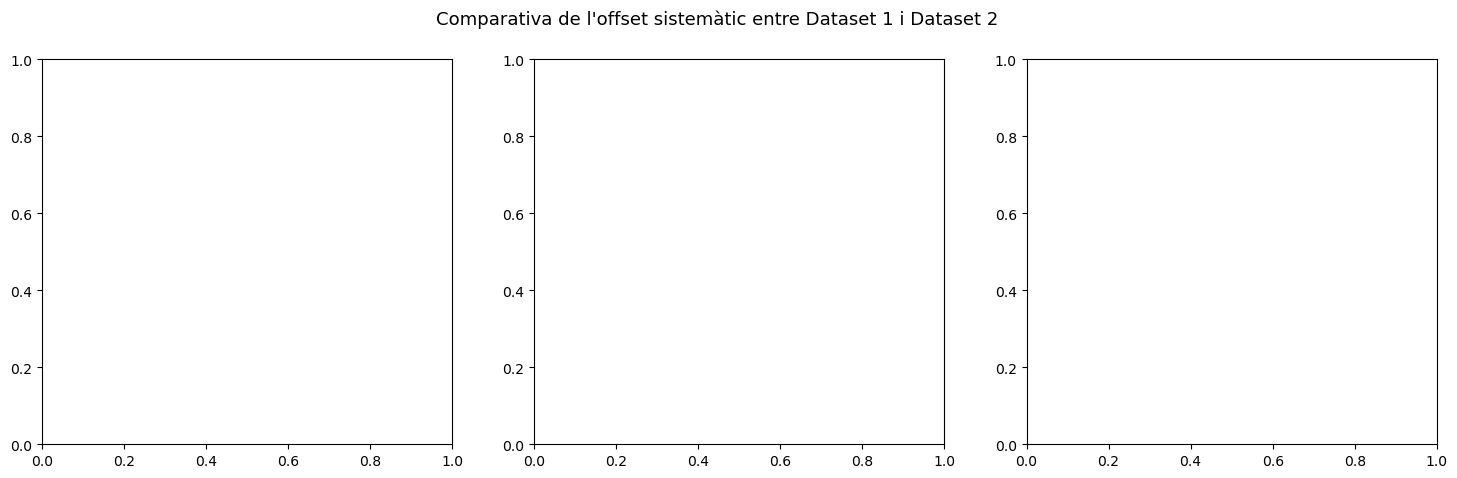

In [207]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparativa de l'offset sistemàtic entre Dataset 1 i Dataset 2", fontsize=13)

# Dataset 1 - errors ja calculats
errors_d1 = {
    'POCO': df_poco_f2_pro_test['d_measured'] - df_poco_f2_pro_test['d_real'],
    'S24U': df_samsung_test['d_measured'] - df_samsung_test['d_real'],
}

# Dataset 2 - errors per dispositiu
errors_d2 = {}
for device in ['POCO', 'GP10', 'S24U']:
    df_dev = df_test1[df_test1['smartphone'] == device]
    errors_all = []
    for ap_id in AP_IDS:
        col_meas = f'dist_ap{ap_id}'
        col_real = f'd_real_ap{ap_id}'
        mask = df_dev[col_meas] != MISSING
        if mask.sum() > 0:
            errs = (df_dev.loc[mask, col_meas] - df_dev.loc[mask, col_real]) / 1000
            errors_all.append(errs)
    if errors_all:
        errors_d2[device] = pd.concat(errors_all)

# Gràfiques CDF per dispositiu comú (POCO i S24U)
for ax, device, title in zip(
    axes,
    ['POCO', 'S24U', 'GP10'],
    ['POCO (F2 Pro vs X3 Pro)', 'Samsung S24 Ultra', 'Google Pixel 10\n(només Dataset 2)']
):
    if device in errors_d1:
        sorted_d1 = np.sort(np.abs(errors_d1[device]))
        cdf_d1 = np.arange(1, len(sorted_d1)+1) / len(sorted_d1)
        ax.plot(sorted_d1, cdf_d1, linewidth=2, 
                color='#e74c3c', label=f'Dataset 1 (RMSE={np.sqrt((errors_d1[device]**2).mean()):.3f} m)')
    
    if device in errors_d2:
        sorted_d2 = np.sort(np.abs(errors_d2[device]))
        cdf_d2 = np.arange(1, len(sorted_d2)+1) / len(sorted_d2)
        ax.plot(sorted_d2, cdf_d2, linewidth=2,
                color='#3498db', label=f'Dataset 2 (RMSE={np.sqrt((errors_d2[device]**2).mean()):.3f} m)')
    
    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=2, color='gray', linestyle=':', alpha=0.3)
    ax.set_xlabel('Error absolut (m)')
    ax.set_ylabel('CDF')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdf_comparativa_datasets.png', dpi=150)
plt.show()